In [2]:
!kaggle datasets download -d akram24/position-salaries

# 4. Unzip the downloaded dataset file
!unzip -o position-salaries.zip

print("\nDataset successfully downloaded and extracted!")

Dataset URL: https://www.kaggle.com/datasets/akram24/position-salaries
License(s): CC0-1.0
100% 333/333 [00:00<00:00, 934kB/s]

Archive:  position-salaries.zip
  inflating: Position_Salaries.csv   

Dataset successfully downloaded and extracted!


### Task 1: Data Understanding

In [3]:
import pandas as pd

df = pd.read_csv('Position_Salaries.csv')

display(df.head())

display(df.info())
display(df.describe())

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


None

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


### Task 2: Data Preprocessing

In [4]:
from sklearn.model_selection import train_test_split

print("Missing Values:\n", df.isnull().sum())

X = df[['Level']].values
y = df['Salary'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Missing Values:
 Position    0
Level       0
Salary      0
dtype: int64


### Task 3: Model Development

In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=3)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

model = LinearRegression()
model.fit(X_poly_train, y_train)

y_pred = model.predict(X_poly_test)

### Task 4: Model Evaluation

Mean Absolute Error (MAE): 70635.25
Mean Squared Error (MSE): 6263853282.86
R2 Score: 0.8763


/tmp/ipykernel_1079/298055844.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X) + 0.1, 0.1).reshape(-1, 1)


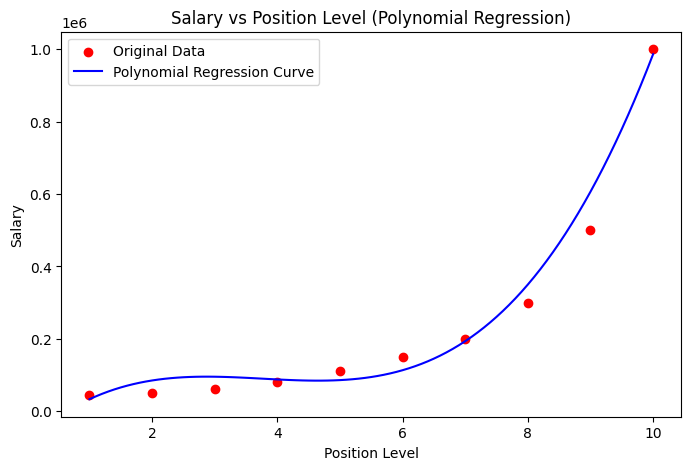

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R2 Score: {r2:.4f}")

X_grid = np.arange(min(X), max(X) + 0.1, 0.1).reshape(-1, 1)
X_grid_poly = poly.transform(X_grid)
y_grid_pred = model.predict(X_grid_poly)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='red', label='Original Data')
plt.plot(X_grid, y_grid_pred, color='blue', label='Polynomial Regression Curve')
plt.title('Salary vs Position Level (Polynomial Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.show()

The polynomial regression curve fits the data points more closely compared to a simple straight line, confirming a non-linear relationship between position level and salary.The $R^{2}$ score indicates the model captures a high percentage of the variance in the salary data, meaning it performs well on the test set.

### Task 5: Conclusion

The primary finding from this analysis is that employee salaries increase exponentially with higher position levels rather than linearly. Standard Linear Regression attempts to fit a straight line to the data, which fails to capture this steep upward trend and leads to significant prediction errors. In contrast, Polynomial Regression introduces polynomial terms that allow the model to bend and closely trace the non-linear curve of the data. The distinct advantage of Polynomial Regression for this specific dataset is its ability to accurately predict salaries for upper-level management positions, which would be heavily underestimated by a simple linear model.